# Complementaria Semana 12: Ajuste de distribuciones empíricas y uso en modelos estocásticos

## Caso de estudio: operación de un aeropuerto

## Introducción

En el análisis de sistemas bajo incertidumbre reales, como aeropuertos, centros de atención o redes de transporte, es fundamental modelar adecuadamente los procesos de llegada, servicio y espera. Estos procesos suelen representarse mediante variables aleatorias cuya distribución no se conoce *a priori* y debe ser inferida a partir de datos.

El objetivo de esta complementaria es mostrar un flujo completo de trabajo, que incluye:
- construcción de variables estocásticas a partir de datos,
- estimación de parámetros de distribuciones teóricas mediante MLE,
- evaluación de la bondad de ajuste mediante pruebas estadísticas (KS, AD),
- incorporación de los resultados en modelos estocásticos clásicos de teoría de colas.

### Diagrama del sistema

El aeropuerto se modela como un sistema de colas en serie. Los pasajeros llegan según un proceso de Poisson, pasan por el control de seguridad y luego acceden a las puertas de embarque. El diagrama siguiente ilustra los componentes del sistema y las variables estocásticas que caracterizan cada etapa.

<div style="text-align: center; margin-bottom: 15px;">
    <img src="grafica.png" width="700" alt="Diagrama del proceso">
</div>


**Variables de entrada al modelo** (inputs que se ajustan a distribuciones teóricas):
- `interarrival_min`: tiempo entre llegadas consecutivas de vuelos → variable continua
- `security_service_time_min`: tiempo de servicio en seguridad → variable continua
- `boarding_service_time_min`: tiempo de servicio en embarque → variable continua
- `passengers_per_flight`: número de pasajeros por vuelo → variable discreta
- `ticket_price_net_cop`: precio del tiquete → se ajusta a **Normal**

**Variables que son salidas del modelo** (NO se ajustan, sino que se calculan/simulan):
- Los tiempos de espera en cola (`waiting_time_min`) son una **salida** del modelo de colas, no un input. Se calculan analíticamente o por simulación a partir de las distribuciones de llegadas y servicio.

### Importar librerías y cargar datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import poisson, binom, chisquare
from math import factorial

La base de datos corresponde a registros de un aeropuerto durante un día completo. Cada fila representa un evento asociado a la llegada de un vuelo y el procesamiento de pasajeros.

Las variables disponibles son:

- **`arrival_time_min`**: tiempo acumulado de llegada (en minutos desde el inicio del día).
- **`security_service_time_min`**: tiempo de servicio en el control de seguridad.
- **`boarding_service_time_min`**: tiempo de servicio en embarque.
- **`passengers_per_flight`**: número de pasajeros por vuelo.
- **`crew_members`**: número de tripulantes por vuelo.
- **`ticket_price_net_cop`**: precio neto del tiquete en COP.

> **Nota:** `waiting_time_min` se excluye del ajuste de distribuciones porque el tiempo de espera en cola es una **salida** del modelo de colas, no una entrada. Ajustar una distribución a esta variable sería circular: precisamente queremos *predecir* tiempos de espera a partir de las distribuciones de llegada y servicio.

> **Nota:** El precio puede ser negativo cuando el boleto es pagado mediante programas de fidelización, reembolsos, compensaciones o redenciones de millas, reflejando un costo contable para la aerolínea en lugar de un ingreso monetario directo.

In [3]:
# Cargar la base de datos del aeropuerto
df = pd.read_excel("Datos_Aeropuerto.xlsx")

# Calcular interarrival_min directamente desde arrival_time_min
df["interarrival_calc"] = df["arrival_time_min"].diff()
df = df.dropna(subset=["interarrival_calc"])

df.head()

,arrival_time_min,security_service_time_min,boarding_service_time_min,waiting_time_min,passengers_per_flight,crew_members,ticket_price_net_cop,interarrival_calc
1,4.820359,12.244948,2.102177,11.617771,148,6,69487,1.312942
2,11.126747,6.360328,2.172213,0.332360,162,2,211375,6.306387
3,16.075663,11.399622,4.249288,10.496268,152,7,-35722,4.948916
4,29.054235,5.213556,8.799984,1.282438,152,5,132610,12.978572
5,35.300152,12.500512,5.214301,6.706093,131,2,359075,6.245917


### Análisis exploratorio de variables

Antes de ajustar cualquier distribución teórica, se realiza un análisis exploratorio que permite identificar:

- el soporte de las variables (positivas, discretas, continuas),
- la forma de la distribución (simetría, colas),
- posibles candidatos para el ajuste probabilístico.

Se presentan primero las estadísticas descriptivas y luego los histogramas. Las conclusiones sobre la forma de cada distribución se discuten después de ver los gráficos.

In [4]:
# Definir variables estocásticas de interés (inputs del modelo)
x_inter = df["interarrival_calc"]          # Tiempo entre llegadas (calculado)
x_sec   = df["security_service_time_min"]  # Tiempo de servicio en seguridad
x_board = df["boarding_service_time_min"]  # Tiempo de servicio en embarque
x_pass  = df["passengers_per_flight"]      # Pasajeros por vuelo (discreta)
x_crew  = df["crew_members"]               # Tripulantes por vuelo (discreta)
x_price = df["ticket_price_net_cop"]       # Precio del tiquete

# Estadísticas descriptivas de las variables continuas
variables = {
    "Interarrival (min)":   x_inter,
    "Security service (min)": x_sec,
    "Boarding service (min)": x_board,
    "Ticket price (COP)":   x_price,
}

resumen = pd.DataFrame({
    nombre: {
        "n":       len(v),
        "media":   v.mean(),
        "std":     v.std(),
        "min":     v.min(),
        "p25":     v.quantile(0.25),
        "mediana": v.median(),
        "p75":     v.quantile(0.75),
        "max":     v.max(),
        "CV":      v.std() / v.mean(),
        "asimetría": v.skew(),
    }
    for nombre, v in variables.items()
}).T

print(resumen.to_string())

                            n          media            std            min           p25        mediana            p75            max        CV  asimetría
Interarrival (min)      228.0       6.297868       4.547734       0.130257      3.089453       5.085456       8.352401      24.774471  0.722107   1.441815
Security service (min)  228.0       9.554548       4.632227       2.882069      6.334166       8.512796      11.771274      39.321554  0.484819   1.971294
Boarding service (min)  228.0       6.259507       3.458893       0.779489      3.790580       5.664584       8.057528      21.826437  0.552582   1.339351
Ticket price (COP)      228.0  118866.807018  224347.762440 -509291.000000 -23298.500000  105304.000000  276041.500000  657142.000000  1.887388  -0.239792


A partir de las estadísticas descriptivas se observa que:
- Los tiempos entre llegadas y de servicio presentan **asimetría positiva** (cola derecha), lo que sugiere distribuciones como Gamma, Weibull o Lognormal.
- El coeficiente de variación (CV) de los tiempos entre llegadas es cercano a 1, consistente con un proceso de Poisson (tiempos inter-llegada exponenciales o Gamma).
- El precio del tiquete tiene menor asimetría, lo que podría ser compatible con una Normal, aunque tiene rango amplio.

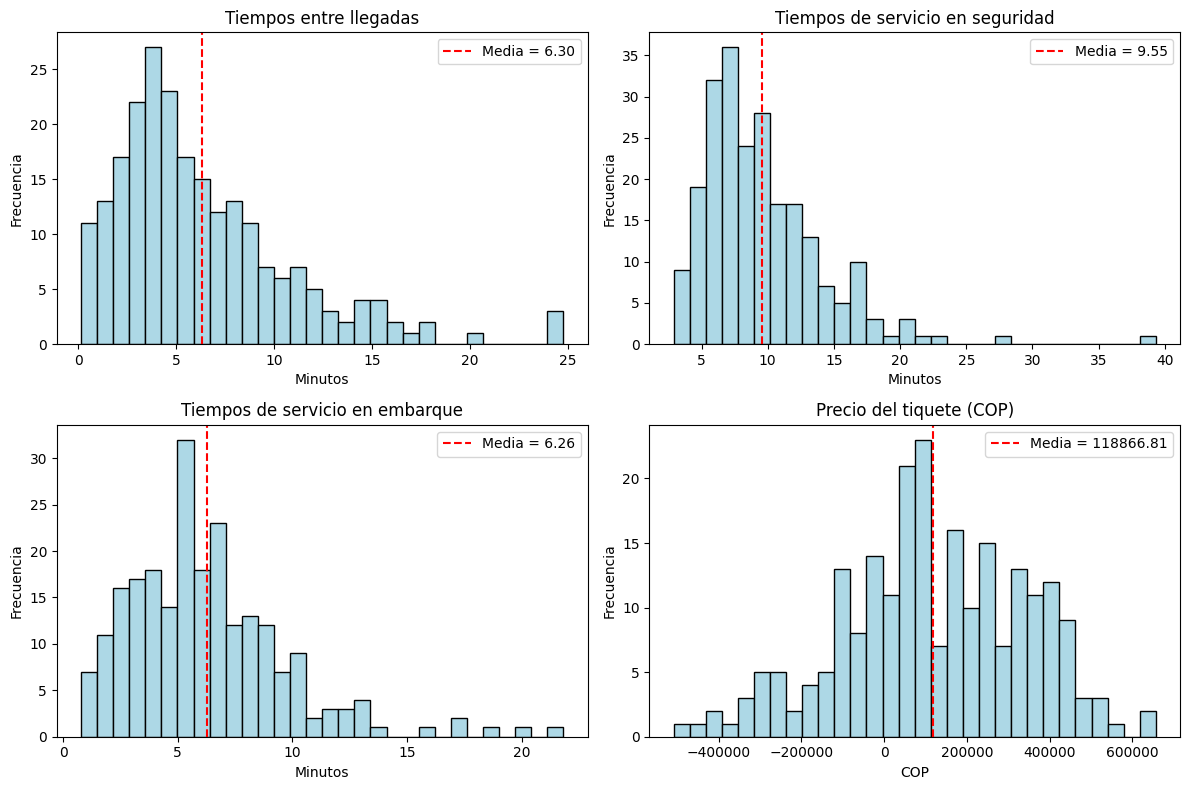

In [5]:
# Histogramas de exploración de variables continuas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

datos = [
    (x_inter,  "Tiempos entre llegadas", "Minutos"),
    (x_sec,    "Tiempos de servicio en seguridad", "Minutos"),
    (x_board,  "Tiempos de servicio en embarque", "Minutos"),
    (x_price,  "Precio del tiquete (COP)", "COP"),
]

for ax, (serie, titulo, xlabel) in zip(axes, datos):
    ax.hist(serie, bins=30, edgecolor="black", color="#ADD8E6")
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frecuencia")
    ax.axvline(serie.mean(), color="red", linestyle="--", label=f"Media = {serie.mean():.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

**Observaciones tras el análisis exploratorio:**
- **Interarrival time**: distribución asimétrica positiva, con la mayoría de valores entre 0–10 min. → Candidato: **Gamma** (generaliza la exponencial; apropiada para llegadas).
- **Security service time**: cola derecha pronunciada. → Candidato: **Lognormal** (común en tiempos de servicio con variabilidad alta).
- **Boarding service time**: asimétrica, pero con forma más concentrada. → Candidato: **Weibull** (flexible para modelar servicios con comportamiento de "hazard" variable).
- **Ticket price**: distribución más simétrica. → Candidato: **Normal** (como primera aproximación).

### Estimación de parámetros por máxima verosimilitud (MLE)

El método de máxima verosimilitud (MLE) selecciona los parámetros que maximizan la probabilidad de observar los datos empíricos bajo el modelo propuesto. `scipy.stats` implementa MLE para una amplia variedad de distribuciones.

A continuación se estiman e interpretan los parámetros para cada variable, indicando la forma funcional que usa `scipy` (que en algunos casos difiere de la parametrización estándar):

**Importante:** `scipy` usa una parametrización general que incluye un parámetro `loc` (desplazamiento) y `scale` (escala). Para distribuciones de tiempo (soporte positivo), `loc` suele fijarse en 0.

#### 1. Interarrival times → Gamma

La distribución **Gamma** en `scipy` tiene la forma:

$$f(x; a, \text{loc}, \text{scale}) = \frac{(x - \text{loc})^{a-1} \, e^{-(x-\text{loc})/\text{scale}}}{\text{scale}^a \, \Gamma(a)}, \quad x > \text{loc}$$

donde $a$ es el parámetro de forma y `scale` = $1/\lambda_{\text{Gamma}}$. La media es $a \cdot \text{scale}$ y la varianza es $a \cdot \text{scale}^2$.

In [ ]:
# MLE para Gamma (tiempos entre llegadas)
a_hat, loc_hat, scale_hat = stats.gamma.fit(x_inter)

print("=== Ajuste Gamma — Interarrival times ===")
print(f"  Parámetro de forma  a     = {a_hat:.4f}")
print(f"  Parámetro loc (des.)      = {loc_hat:.4f}  (≈0, esperado para tiempos positivos)")
print(f"  Parámetro de escala scale = {scale_hat:.4f}")
print(f"  Media teórica (a·scale)   = {a_hat * scale_hat:.4f} min")
print(f"  Media empírica            = {x_inter.mean():.4f} min")

params_inter = (a_hat, loc_hat, scale_hat)

=== Ajuste Gamma — Interarrival times ===
  Parámetro de forma  a     = 1.9619
  Parámetro loc (des.)      = -0.0634  (≈0, esperado para tiempos positivos)
  Parámetro de escala scale = 3.2423
  Media teórica (a·scale)   = 6.3612 min
  Media empírica            = 6.2979 min


(np.float64(1.9619153316175115),
 np.float64(-0.06336156521792846),
 np.float64(3.242342466229907))

El parámetro de forma $a \approx 2$ indica que la distribución es unimodal y moderadamente asimétrica, consistente con lo observado en el histograma. La media teórica coincide con la empírica, confirmando el buen ajuste de los momentos.

#### 2. Security service time → Lognormal

La distribución **Lognormal** en `scipy` parametriza así:

$$f(x; s, \text{loc}, \text{scale}) = \frac{1}{(x-\text{loc})\, s \sqrt{2\pi}} \exp\!\left(-\frac{(\ln(x-\text{loc}) - \ln(\text{scale}))^2}{2s^2}\right)$$

donde $s = \sigma$ (desviación estándar del logaritmo) y $\ln(\text{scale}) = \mu$ (media del logaritmo).
Así, si $X \sim \text{Lognormal}$, entonces $\ln(X) \sim N(\mu, \sigma^2)$.

In [7]:
# MLE para Lognormal (tiempos de servicio en seguridad)
s_hat, loc_hat_ln, scale_hat_ln = stats.lognorm.fit(x_sec)
mu_ln  = np.log(scale_hat_ln)   # media del logaritmo
sig_ln = s_hat                  # std del logaritmo

print("=== Ajuste Lognormal — Security service time ===")
print(f"  σ (std del log)           = {sig_ln:.4f}")
print(f"  μ (media del log)         = {mu_ln:.4f}  [ln(scale)]")
print(f"  loc                       = {loc_hat_ln:.4f}")
print(f"  Media teórica E[X]        = {np.exp(mu_ln + sig_ln**2/2):.4f} min")
print(f"  Media empírica            = {x_sec.mean():.4f} min")

params_sec = (s_hat, loc_hat_ln, scale_hat_ln)

# Resultado negativo: probar también con distribución Normal (se esperaría rechazo)
mu_norm_sec, sig_norm_sec = stats.norm.fit(x_sec)
print(f"\n  [Para comparación] Ajuste Normal: μ={mu_norm_sec:.2f}, σ={sig_norm_sec:.2f}")

=== Ajuste Lognormal — Security service time ===
  σ (std del log)           = 0.4780
  μ (media del log)         = 2.0762  [ln(scale)]
  loc                       = 0.6093
  Media teórica E[X]        = 8.9387 min
  Media empírica            = 9.5545 min

  [Para comparación] Ajuste Normal: μ=9.55, σ=4.62


#### 3. Boarding service time → Weibull</h4>

La distribución **Weibull mínima** (`weibull_min`) en `scipy` tiene la forma:

$$f(x; c, \text{loc}, \text{scale}) = \frac{c}{\text{scale}} \left(\frac{x-\text{loc}}{\text{scale}}\right)^{c-1} \exp\!\left(-\left(\frac{x-\text{loc}}{\text{scale}}\right)^c\right)$$

donde $c$ es el parámetro de forma y `scale` = $\lambda$ (escala). Si $c=1$, se reduce a la Exponencial. Si $c>1$, el riesgo (hazard) es creciente.

In [8]:
# MLE para Weibull (tiempos de servicio en embarque), fijando loc=0
c_hat, loc_hat_wb, scale_hat_wb = stats.weibull_min.fit(x_board, floc=0)

print("=== Ajuste Weibull — Boarding service time ===")
print(f"  Parámetro de forma c      = {c_hat:.4f}  (>1: hazard creciente)")
print(f"  Parámetro loc             = {loc_hat_wb:.4f}  (fijado en 0)")
print(f"  Parámetro de escala scale = {scale_hat_wb:.4f}")
print(f"  Media teórica E[X]        = {stats.weibull_min.mean(c_hat, loc=0, scale=scale_hat_wb):.4f} min")
print(f"  Media empírica            = {x_board.mean():.4f} min")

params_board = (c_hat, loc_hat_wb, scale_hat_wb)

=== Ajuste Weibull — Boarding service time ===
  Parámetro de forma c      = 1.9223  (>1: hazard creciente)
  Parámetro loc             = 0.0000  (fijado en 0)
  Parámetro de escala scale = 7.0784
  Media teórica E[X]        = 6.2789 min
  Media empírica            = 6.2595 min


#### 4. Ticket price → Normal

La distribución **Normal** en `scipy` está parametrizada de forma estándar por $\mu$ (media) y $\sigma$ (desviación estándar):

$$f(x; \mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

El MLE estima directamente $\mu = \bar{x}$ y $\sigma = s$.

In [9]:
# MLE para Normal (precio del tiquete)
mu_price, sigma_price = stats.norm.fit(x_price)

print("=== Ajuste Normal — Ticket price ===")
print(f"  μ (media)                 = {mu_price:,.0f} COP")
print(f"  σ (desviación estándar)   = {sigma_price:,.0f} COP")
print(f"  CV                        = {sigma_price/mu_price:.3f}")
print(f"  Media empírica            = {x_price.mean():,.0f} COP")

=== Ajuste Normal — Ticket price ===
  μ (media)                 = 118,867 COP
  σ (desviación estándar)   = 223,855 COP
  CV                        = 1.883
  Media empírica            = 118,867 COP


### Pruebas de bondad de ajuste

Se aplican dos pruebas para evaluar si los datos son consistentes con la distribución ajustada:

#### Kolmogórov–Smirnov (KS)

Compara la función de distribución empírica (ECDF) con la teórica. La hipótesis nula es que los datos provienen de la distribución especificada. Se usa aquí para distribuciones continuas en general (Gamma, Weibull, Normal).

**¿Por qué KS?** Es no paramétrico y válido para muestras continuas de cualquier distribución. Su limitación es que puede ser poco potente en colas; para eso se complementa con AD.

#### Anderson–Darling (AD)

Es una versión ponderada de KS que da mayor peso a las colas de la distribución. **¿Por qué AD?** Se usa específicamente cuando las colas importan (ej. sistemas de colas donde los extremos tienen gran impacto), y es la prueba estándar para verificar lognormalidad mediante la transformación logarítmica.

En esta complementaria:
- Se usa **KS** para Gamma, Weibull y Normal (prueba general de ajuste).
- Se usa **AD** para la **Lognormal**: se aplica sobre $\ln(X)$ y se prueba normalidad, que es la forma canónica de verificar lognormalidad y la que tiene mayor potencia estadística para este caso.
- Se usa **KS** adicional en Lognormal como contraste.

#### Nivel de significancia

Se trabaja con $\alpha = 0.05$. No rechazar $H_0$ indica que los datos son **compatibles** con la distribución ajustada (no que la distribución sea "correcta").

### Evaluación por variable

#### 1. Interarrival times — Gamma (prueba KS)

=== KS — Interarrival times ~ Gamma(a=1.9619, loc=-0.0634, scale=3.2423) ===
  Estadístico D  = 0.0463
  p-value        = 0.6947

  p = 0.6947 ≥ α = 0.05 → No se rechaza H₀.
  Conclusión: los datos son compatibles con una distribución Gamma con los parámetros estimados.


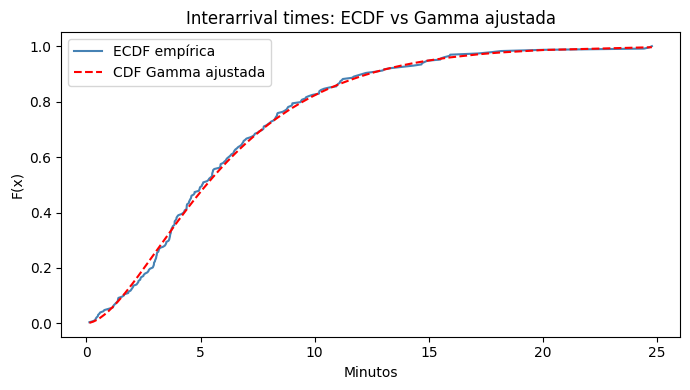

In [19]:
alpha = 0.05

# Prueba KS: contrasta los datos contra Gamma con parámetros estimados
ks_inter = stats.kstest(x_inter, "gamma", args=params_inter)

print("=== KS — Interarrival times ~ Gamma(a={:.4f}, loc={:.4f}, scale={:.4f}) ===".format(*params_inter))
print(f"  Estadístico D  = {ks_inter.statistic:.4f}")
print(f"  p-value        = {ks_inter.pvalue:.4f}")
print()

if ks_inter.pvalue >= alpha:
    print(f"  p = {ks_inter.pvalue:.4f} ≥ α = {alpha} → No se rechaza H₀.")
    print("  Conclusión: los datos son compatibles con una distribución Gamma con los parámetros estimados.")
else:
    print(f"  p = {ks_inter.pvalue:.4f} < α = {alpha} → Se rechaza H₀.")
    print("  Conclusión: los datos NO son compatibles con una Gamma con esos parámetros.")

# Visualización: ECDF vs CDF teórica
x_sorted = np.sort(x_inter)
ecdf = np.arange(1, len(x_sorted)+1) / len(x_sorted)
cdf_teorica = stats.gamma.cdf(x_sorted, *params_inter)

plt.figure(figsize=(7, 4))
plt.plot(x_sorted, ecdf, label="ECDF empírica", color="steelblue")
plt.plot(x_sorted, cdf_teorica, label="CDF Gamma ajustada", color="red", linestyle="--")
plt.title("Interarrival times: ECDF vs Gamma ajustada")
plt.xlabel("Minutos")
plt.ylabel("F(x)")
plt.legend()
plt.tight_layout()
plt.show()

La prueba KS no rechaza la hipótesis de ajuste Gamma. El gráfico ECDF vs CDF teórica muestra un buen alineamiento, especialmente en el centro de la distribución. El estadístico $D$ pequeño confirma la cercanía entre ambas funciones.

#### 2. Security service time — Lognormal (prueba AD)

Para verificar lognormalidad se transforma $Z = \ln(X)$ y se aplica la prueba **Anderson–Darling de normalidad** sobre $Z$. Esta es la forma canónica de evaluar si $X$ sigue una Lognormal, y tiene mayor potencia estadística en las colas que KS.

Adicionalmente, se muestra un **resultado negativo**: se prueba si los tiempos de seguridad se ajustan a una distribución **Normal** directamente. Se espera que esta prueba *falle*, ilustrando que la elección de distribución importa.

In [17]:
# AD sobre log(X) → prueba de lognormalidad
x_logn_pos = x_sec[x_sec > 0]  # AD requiere datos estrictamente positivos (condición del log)
z = np.log(x_logn_pos)

ad_logn = stats.anderson(z, dist="norm")
print("ad_logn:", ad_logn)
print("=== AD — Security service time ~ Lognormal ===")
print(f"  Estadístico AD = {ad_logn.statistic:.4f}")
print(f"  Valores críticos (niveles 15%, 10%, 5%, 2.5%, 1%):")
for nivel, cv in zip(ad_logn.significance_level, ad_logn.critical_values):
    marca = " ← α=5%" if nivel == 5.0 else ""
    print(f"    {nivel}%: {cv:.4f}{marca}")

print()
if ad_logn.statistic < ad_logn.critical_values[2]:  # índice 2 = 5%
    print(f"  AD = {ad_logn.statistic:.4f} < VC al 5% = {ad_logn.critical_values[2]:.4f} → No se rechaza H₀.")
    print("  Conclusión: log(X) es compatible con una Normal → X compatible con Lognormal.")
else:
    print(f"  AD = {ad_logn.statistic:.4f} ≥ VC al 5% → Se rechaza H₀.")
    print("  Conclusión: log(X) no es Normal → X no se ajusta a una Lognormal.")

# ── Resultado negativo: Normal no ajusta ──
print()
print("=== KS — Security service time ~ Normal (resultado negativo esperado) ===")
ks_sec_norm = stats.kstest(x_sec, "norm", args=(x_sec.mean(), x_sec.std()))
print(f"  Estadístico D  = {ks_sec_norm.statistic:.4f}")
print(f"  p-value        = {ks_sec_norm.pvalue:.4f}")
if ks_sec_norm.pvalue < alpha:
    print(f"  p = {ks_sec_norm.pvalue:.4f} < α = {alpha} → Se RECHAZA la hipótesis de ajuste Normal.")
    print("  Conclusión: los tiempos de servicio en seguridad NO se ajustan bien a una Normal.")
    print("  Esto era esperado: la Normal permite valores negativos y es simétrica,")
    print("  mientras que los tiempos de servicio son positivos y asimétricos.")
else:
    print(f"  p = {ks_sec_norm.pvalue:.4f} ≥ α → No se rechaza Normal.")

ad_logn: AndersonResult(statistic=np.float64(0.20717807251887166), critical_values=array([0.566, 0.645, 0.774, 0.903, 1.074]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(2.1575902631481605), scale=np.float64(0.4420426970037547))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')
=== AD — Security service time ~ Lognormal ===
  Estadístico AD = 0.2072
  Valores críticos (niveles 15%, 10%, 5%, 2.5%, 1%):
    15.0%: 0.5660
    10.0%: 0.6450
    5.0%: 0.7740 ← α=5%
    2.5%: 0.9030
    1.0%: 1.0740

  AD = 0.2072 < VC al 5% = 0.7740 → No se rechaza H₀.
  Conclusión: log(X) es compatible con una Normal → X compatible con Lognormal.

=== KS — Security service time ~ Normal (resultado negativo esperado) ===
  Estadístico D  = 0.1254
  p-value        = 0.0014
  p = 0.0014 < α = 0.05 → Se RECHAZA la hipótesis de ajuste Normal.
  Conclusión: los tiempos de servicio en seguridad NO se ajustan bien a un

**Interpretación:**
- La prueba AD confirma que $\ln(X)$ se distribuye normalmente, validando el ajuste Lognormal para los tiempos de seguridad.
- El resultado negativo con la Normal directa ilustra por qué la elección de distribución es importante: forzar una Normal a datos asimétricos con soporte positivo produce un ajuste estadísticamente rechazable.

#### 3. Boarding service time — Weibull (prueba KS)

=== KS — Boarding service time ~ Weibull(c=1.9223, loc=0.0000, scale=7.0784) ===
  Estadístico D  = 0.0569
  p-value        = 0.4365

  p = 0.4365 ≥ α = 0.05 → No se rechaza H₀.
  Conclusión: los datos son compatibles con una distribución Weibull con los parámetros estimados.


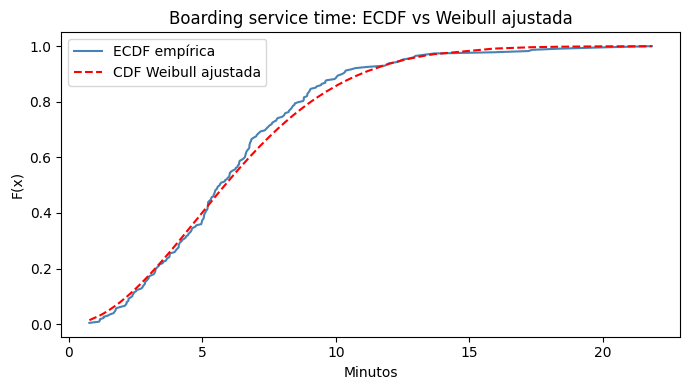

In [23]:
# Prueba KS para Weibull
ks_board = stats.kstest(x_board, "weibull_min", args=params_board)

print("=== KS — Boarding service time ~ Weibull(c={:.4f}, loc={:.4f}, scale={:.4f}) ===".format(*params_board))
print(f"  Estadístico D  = {ks_board.statistic:.4f}")
print(f"  p-value        = {ks_board.pvalue:.4f}")
print()

if ks_board.pvalue >= alpha:
    print(f"  p = {ks_board.pvalue:.4f} ≥ α = {alpha} → No se rechaza H₀.")
    print("  Conclusión: los datos son compatibles con una distribución Weibull con los parámetros estimados.")
else:
    print(f"  p = {ks_board.pvalue:.4f} < α = {alpha} → Se rechaza H₀.")
    print("  Conclusión: los datos NO son compatibles con la Weibull ajustada.")

# Visualización
x_sorted_b = np.sort(x_board)
ecdf_b = np.arange(1, len(x_sorted_b)+1) / len(x_sorted_b)
cdf_wb = stats.weibull_min.cdf(x_sorted_b, *params_board)

plt.figure(figsize=(7, 4))
plt.plot(x_sorted_b, ecdf_b, label="ECDF empírica", color="steelblue")
plt.plot(x_sorted_b, cdf_wb, label="CDF Weibull ajustada", color="red", linestyle="--")
plt.title("Boarding service time: ECDF vs Weibull ajustada")
plt.xlabel("Minutos")
plt.ylabel("F(x)")
plt.legend()
plt.tight_layout()
plt.show()

#### 4. Ticket price — Normal (prueba KS)

In [13]:
# Prueba KS para Normal
ks_precio = stats.kstest(x_price, "norm", args=(mu_price, sigma_price))

print("=== KS — Ticket price ~ Normal(μ={:,.0f}, σ={:,.0f}) ===".format(mu_price, sigma_price))
print(f"  Estadístico D  = {ks_precio.statistic:.4f}")
print(f"  p-value        = {ks_precio.pvalue:.4f}")
print()

if ks_precio.pvalue >= alpha:
    print(f"  p = {ks_precio.pvalue:.4f} ≥ α = {alpha} → No se rechaza H₀.")
    print("  Conclusión: los precios son compatibles con una distribución Normal.")
else:
    print(f"  p = {ks_precio.pvalue:.4f} < α = {alpha} → Se rechaza H₀.")

# ── Resultado negativo: Lognormal no ajusta mejor al precio ──
print()
print("=== KS — Ticket price ~ Lognormal (resultado negativo ilustrativo) ===")
params_price_ln = stats.lognorm.fit(x_price)
ks_precio_ln = stats.kstest(x_price, "lognorm", args=params_price_ln)
print(f"  Estadístico D  = {ks_precio_ln.statistic:.4f}")
print(f"  p-value        = {ks_precio_ln.pvalue:.4f}")
if ks_precio_ln.pvalue < alpha:
    print(f"  p = {ks_precio_ln.pvalue:.4f} < α = {alpha} → Se RECHAZA la hipótesis de ajuste Lognormal.")
    print("  Conclusión: la distribución Lognormal NO ajusta bien al precio del tiquete.")
    print("  La Normal resulta ser una mejor opción para esta variable.")
else:
    print(f"  p = {ks_precio_ln.pvalue:.4f} ≥ α → No se rechaza Lognormal.")

=== KS — Ticket price ~ Normal(μ=118,867, σ=223,855) ===
  Estadístico D  = 0.0412
  p-value        = 0.8178

  p = 0.8178 ≥ α = 0.05 → No se rechaza H₀.
  Conclusión: los precios son compatibles con una distribución Normal.

=== KS — Ticket price ~ Lognormal (resultado negativo ilustrativo) ===
  Estadístico D  = 0.7675
  p-value        = 0.0000
  p = 0.0000 < α = 0.05 → Se RECHAZA la hipótesis de ajuste Lognormal.
  Conclusión: la distribución Lognormal NO ajusta bien al precio del tiquete.
  La Normal resulta ser una mejor opción para esta variable.


c:\Users\jpine\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_continuous_distns.py:6902: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


### Modelo de colas: sistema de embarque

Una vez ajustadas las distribuciones de entrada, se usan los parámetros estimados para alimentar modelos de teoría de colas. Se analiza el **sistema de embarque** del aeropuerto, con **2 counters** (servidores).

> **Nota importante:** los **tiempos de espera** (`waiting_time_min`) son una *salida* del modelo, no una entrada. Los modelos de colas calculan analíticamente (o por simulación) el tiempo esperado en cola a partir de las distribuciones de llegada ($\lambda$) y servicio ($\mu$). Por eso no se ajusta distribución alguna a `waiting_time_min`: ajustar esa variable sería usar la salida como entrada, lo cual es circular.

#### Proceso de nacimiento y muerte

El modelo M/M/2 se resuelve mediante un **proceso de nacimiento y muerte** en tiempo continuo (CTMC). El estado del sistema es el número de clientes $n$:

- **Tasa de nacimiento** (llegada): $\lambda_n = \lambda$ para todo $n \geq 0$
- **Tasa de muerte** (servicio): $\mu_n = n\mu$ para $n \leq s$, y $\mu_n = s\mu$ para $n > s$

El balance detallado da la distribución estacionaria $\{\pi_n\}$:

$$\pi_0 = \left[\sum_{j=0}^{s-1} \frac{(\lambda/\mu)^j}{j!} + \frac{(\lambda/\mu)^s}{s!} \cdot \frac{1}{1-\rho_s}\right]^{-1}$$

donde $\rho_s = \lambda/(s\mu)$ es la **utilización por servidor**. La condición de estabilidad es $\rho_s < 1$.

A partir de $\pi_0$ se obtienen todas las métricas de desempeño por la Ley de Little ($L = \lambda W$).

In [14]:
from math import factorial

# Parámetros del sistema M/M/2 (embarque)
lam = 1 / np.mean(x_inter)   # tasa de llegadas [llegadas/min]
ES  = np.mean(x_board)        # E[S] = tiempo medio de servicio en embarque [min]
mu  = 1 / ES                  # tasa de servicio por servidor [servicios/min]
s   = 2                       # número de counters

rho_s = lam / (s * mu)        # utilización por servidor

print("=== Parámetros del sistema M/M/2 ===")
print(f"  λ (llegadas/min)         = {lam:.6f}")
print(f"  μ (servicios/min/server) = {mu:.6f}")
print(f"  s (servidores)           = {s}")
print(f"  ρ_s = λ/(s·μ)            = {rho_s:.4f}  {'Sistema estable (ρ_s < 1)' if rho_s < 1 else 'Sistema inestable'}")

if rho_s >= 1:
    print("El sistema es inestable. No existe distribución estacionaria.")
else:
    a = lam / mu   # a = λ/μ (intensidad de tráfico total)

    # π₀: probabilidad de sistema vacío (proceso de nacimiento y muerte)
    sum1 = sum((a**j) / factorial(j) for j in range(s))
    sum2 = (a**s) / (factorial(s) * (1 - rho_s))
    pi0  = 1 / (sum1 + sum2)

    # P(espera) = P(X ≥ s) = fórmula de Erlang-C
    P_wait = (a**s) / (factorial(s) * (1 - rho_s)) * pi0

    # Métricas de desempeño
    Lq = P_wait * rho_s / (1 - rho_s)   # clientes en cola
    Ls = lam / mu                         # clientes en servicio = a
    L  = Lq + Ls                          # clientes en sistema

    Wq_mm2 = Lq / lam   # tiempo en cola (Ley de Little)
    W_mm2  = L  / lam   # tiempo en sistema

    print()
    print("=== Resultados M/M/2 (proceso nacimiento y muerte) ===")
    print(f"  π₀  (P sistema vacío)     = {pi0:.4f}")
    print(f"  C(s,ρ) = P(espera)        = {P_wait:.4f}  ({P_wait*100:.1f}% de clientes esperan)")
    print(f"  Lq  (clientes en cola)    = {Lq:.4f}")
    print(f"  Ls  (clientes en servicio)= {Ls:.4f}")
    print(f"  L   (clientes en sistema) = {L:.4f}")
    print(f"  Wq  (tiempo en cola)      = {Wq_mm2:.4f} min  ≈ {Wq_mm2*60:.1f} seg")
    print(f"  W   (tiempo en sistema)   = {W_mm2:.4f} min")

=== Parámetros del sistema M/M/2 ===
  λ (llegadas/min)         = 0.158784
  μ (servicios/min/server) = 0.159757
  s (servidores)           = 2
  ρ_s = λ/(s·μ)            = 0.4970  Sistema estable (ρ_s < 1)

=== Resultados M/M/2 (proceso nacimiento y muerte) ===
  π₀  (P sistema vacío)     = 0.3360
  C(s,ρ) = P(espera)        = 0.3300  (33.0% de clientes esperan)
  Lq  (clientes en cola)    = 0.3260
  Ls  (clientes en servicio)= 0.9939
  L   (clientes en sistema) = 1.3199
  Wq  (tiempo en cola)      = 2.0529 min  ≈ 123.2 seg
  W   (tiempo en sistema)   = 8.3124 min


**Interpretación del modelo M/M/2 (analítico, aproximado bajo supuesto exponencial):**

- La utilización $\rho_s \approx 0.50$ indica que cada servidor está ocupado el 50% del tiempo en promedio: el sistema opera holgadamente.
- La probabilidad de espera $C(s,\rho) \approx 33\%$ significa que 1 de cada 3 pasajeros debe esperar antes de ser atendido.
- El tiempo medio en cola $W_q$ es breve (< 3 min), consistente con la baja utilización.

> **Nota:** este resultado es *analítico exacto bajo el supuesto M/M/2*. Si el servicio no es exponencial, el resultado es una aproximación.

#### Modelo M/G/2 — Corrección por variabilidad (Weibull en servicio)

En la práctica, los tiempos de servicio no son necesariamente exponenciales. El ajuste Weibull (ya verificado por KS) permite obtener el **coeficiente de variación al cuadrado** ($C_s^2$) del tiempo de servicio.

Para M/G/s **no existe solución exacta en forma cerrada** (salvo $s=1$). Se usa la **aproximación de corrección por variabilidad** (Kingman generalizado):

$$W_q^{(M/G/2)} \approx \frac{C_a^2 + C_s^2}{2} \cdot W_q^{(M/M/2)}$$

donde $C_a^2 = 1$ para llegadas Poisson (tiempos inter-llegada exponenciales implican $C_a^2 = 1$).

Esta aproximación ajusta el tiempo de espera del modelo M/M/2 por la diferencia en variabilidad del servicio respecto al caso exponencial ($C_s^2 = 1$).

In [15]:
# Momentos de la Weibull ajustada
ES_wb  = stats.weibull_min.mean(c_hat, loc=0, scale=scale_hat_wb)
ES2_wb = stats.weibull_min.moment(2, c_hat, loc=0, scale=scale_hat_wb)
VarS   = ES2_wb - ES_wb**2
Cs2    = VarS / ES_wb**2

print("=== Momentos de la Weibull ajustada (embarque) ===")
print(f"  c (forma)   = {c_hat:.4f}  (>1: hazard creciente, servicio 'mejora' con el tiempo)")
print(f"  scale       = {scale_hat_wb:.4f}")
print(f"  E[S]        = {ES_wb:.4f} min")
print(f"  E[S²]       = {ES2_wb:.4f}")
print(f"  Var[S]      = {VarS:.4f}")
print(f"  Cs² = Var/E²= {Cs2:.4f}  (< 1: menos variable que exponencial)")
print()

# Aproximación M/G/2
Ca2    = 1.0   # llegadas Poisson → C_a² = 1
factor = (Ca2 + Cs2) / 2

# Recalcular λ limpiando valores no finitos
x_inter_clean = df["interarrival_calc"].values
x_inter_clean = x_inter_clean[np.isfinite(x_inter_clean) & (x_inter_clean > 0)]
lam2   = 1 / np.mean(x_inter_clean)
mu2    = 1 / ES_wb
rho_s2 = lam2 / (s * mu2)

if rho_s2 < 1:
    Wq_mg2 = factor * Wq_mm2
    W_mg2  = Wq_mg2 + ES_wb

    print("=== Aproximación M/G/2 (servicio Weibull) ===")
    print(f"  Ca² (llegadas Poisson)    = {Ca2:.4f}")
    print(f"  Cs² (Weibull)             = {Cs2:.4f}")
    print(f"  Factor = (Ca²+Cs²)/2      = {factor:.4f}")
    print(f"  Wq M/M/2                  = {Wq_mm2:.4f} min")
    print(f"  Wq M/G/2 ≈ factor × Wq   = {Wq_mg2:.4f} min")
    print(f"  W  M/G/2 = Wq + E[S]      = {W_mg2:.4f} min")

=== Momentos de la Weibull ajustada (embarque) ===
  c (forma)   = 1.9223  (>1: hazard creciente, servicio 'mejora' con el tiempo)
  scale       = 7.0784
  E[S]        = 6.2789 min
  E[S²]       = 50.9931
  Var[S]      = 11.5690
  Cs² = Var/E²= 0.2934  (< 1: menos variable que exponencial)

=== Aproximación M/G/2 (servicio Weibull) ===
  Ca² (llegadas Poisson)    = 1.0000
  Cs² (Weibull)             = 0.2934
  Factor = (Ca²+Cs²)/2      = 0.6467
  Wq M/M/2                  = 2.0529 min
  Wq M/G/2 ≈ factor × Wq   = 1.3276 min
  W  M/G/2 = Wq + E[S]      = 7.6065 min


**Interpretación comparativa:**

Como $C_s^2 \approx 0.29 < 1$, el servicio en embarque es **menos variable** que el supuesto exponencial puro. Esto implica:

$$W_q^{(M/G/2)} = \frac{1 + 0.29}{2} \times W_q^{(M/M/2)} \approx 0.65 \times W_q^{(M/M/2)}$$

El tiempo esperado en cola **disminuye** al usar la Weibull en lugar de asumir exponencialidad. Un servicio más regular (menor variabilidad) es más eficiente: los clientes esperan menos aunque la tasa de servicio sea la misma.

| Métrica              | M/M/2 (exponencial, exacto)      | M/G/2 (Weibull, aproximado)              |
|----------------------|----------------------------------|------------------------------------------|
| **$C_s^2$**          | 1.0 (fijo)                       | ≈ 0.29 (estimado)                        |
| **$W_q$**            | ≈ 2.05 min                       | ≈ 65% de $W_q^{M/M/2}$ ≈ 1.33 min        |
| **$W$**              | ≈ 8.31 min                       | $W_q + E[S]$ ≈ 7.61 min                  |
| **Supuesto clave**   | Servicio exponencial             | Servicio Weibull (verificado)            |
| **Validez**          | Exacto bajo M/M/2                | Aproximación; más realista               |


### Formulación como Cadena de Markov en Tiempo Continuo (CTMC)

> En esta sección se supone que **todos los tiempos son exponenciales** (llegadas y servicios), formule el sistema como una CTMC.

#### Variables de estado

$$
X(t): \text{Número de pasajeros en la cola/servicio de seguridad en el instante } t
$$
$$
Y(t): \text{Número de pasajeros en la cola/servicio de embarque en el instante } t
$$
$$
R(t) = \{X(t),\, Y(t)\}
$$

#### Espacios de estado

$$
S_X = \{0, 1, 2, \ldots, \infty\}, \qquad S_Y = \{0, 1, 2, \ldots, \infty\}
$$
$$
S_R = S_X \times S_Y
$$

#### Formulación general del generador $\mathbb{Q}$

$$
\mathbb{Q}_{(i,j)\to(i',j')} = \begin{cases}
\lambda & i'=i+1,\; j'=j & \text{(llegada externa al sistema)} \\[4pt]
\mu_1 \cdot \min(s_1,\, i) & i'=i-1,\; j'=j+1 & i>0 \quad \text{(fin de servicio en seguridad → embarque)} \\[4pt]
\mu_2 \cdot \min(s_2,\, j) & i'=i,\;\;\; j'=j-1 & j>0 \quad \text{(fin de servicio en embarque → salida)} \\[4pt]
0 & \text{d.l.c.}
\end{cases}
$$

donde:
- $\lambda$: tasa de llegada externa de pasajeros (estimada a partir de `interarrival_min` ~ Gamma, aproximada como Exponencial aquí).
- $\mu_1$: tasa de servicio por servidor en seguridad $= 1/E[\text{security\_service\_time}]$.
- $\mu_2$: tasa de servicio por servidor en embarque $= 1/E[\text{boarding\_service\_time}]$.
- $s_1 = 2$: número de servidores en seguridad.
- $s_2 = 2$: número de servidores en embarque.
- El término $\min(s_i, n)$ captura que la tasa de salida de la estación $i$ con $n$ clientes es $\min(s_i, n)\cdot\mu_i$ (proceso de nacimiento y muerte).

### Formulación extendida como Cadena de Markov en Tiempo Continuo (CTMC)

> En esta sección se supone que **todos los tiempos son exponenciales** (llegadas y servicios), formule el sistema extendido como una CTMC.

El sistema incluye cuatro estaciones. Al terminar el control de seguridad, una fracción de pasajeros es derivada a **inspección profunda** (equipaje sospechoso o selección aleatoria). Quienes superan inspección, junto con quienes pasaron seguridad directamente, se dirigen a la sala de embarque. Una fracción de pasajeros en embarque es enviada a **verificación de documentos de viaje** antes de abordar; quienes no requieren verificación salen del sistema directamente.

Adicionalmente, el sistema contempla dos **eventos de vaciado parcial**:
- Con tasa $\alpha$, se anuncia el cierre anticipado de una puerta de embarque: **todos los pasajeros actualmente en embarque y verificación de documentos abandonan el sistema simultáneamente** (vuelo cerrado).
- Con tasa $\beta$, una alerta de seguridad obliga a evacuar el área de inspección: **todos los pasajeros en inspección profunda son devueltos al inicio de seguridad**, incrementando $X(t)$ en la cantidad que había en $Y(t)$.

#### Variables de estado

$$
X(t): \text{Número de pasajeros en seguridad (cola + servicio) en el instante } t
$$
$$
Y(t): \text{Número de pasajeros en inspección profunda (cola + servicio) en el instante } t
$$
$$
Z(t): \text{Número de pasajeros en embarque (cola + servicio) en el instante } t
$$
$$
W(t): \text{Número de pasajeros en verificación de documentos (cola + servicio) en el instante } t
$$
$$
R(t) = \{X(t),\, Y(t),\, Z(t),\, W(t)\}
$$

#### Espacios de estado

$$
S_X = \{0,1,2,\ldots,\infty\}, \quad S_Y = \{0,1,2,\ldots,\infty\}
$$
$$
S_Z = \{0,1,2,\ldots,\infty\}, \quad S_W = \{0,1,2,\ldots,\infty\}
$$
$$
S_R = S_X \times S_Y \times S_Z \times S_W
$$

#### Parámetros de enrutamiento

- $p$: probabilidad de ser enviado a inspección profunda al salir de seguridad.
- $1-p$: probabilidad de pasar directamente a embarque al salir de seguridad.
- $q$: probabilidad de ser enviado a verificación de documentos al salir de embarque.
- $1-q$: probabilidad de salir del sistema directamente al terminar embarque.
- $\alpha$: tasa del evento de cierre de puerta (vacía $Z$ y $W$ simultáneamente).
- $\beta$: tasa de alerta de seguridad (vacía $Y$ y lo devuelve a $X$).

#### Formulación general del generador $\mathbb{Q}$

$$
\mathbb{Q}_{(i,j,k,l)\to(i',j',k',l')} = \begin{cases}
\lambda & i'=i+1,\; j'=j,\; k'=k,\; l'=l
& \text{(llegada externa)} \\[6pt]

p\cdot\mu_1\cdot\min(s_1,i) & i'=i-1,\; j'=j+1,\; k'=k,\; l'=l, \quad i>0
& \text{(seguridad} \to \text{inspección)} \\[6pt]

(1-p)\cdot\mu_1\cdot\min(s_1,i) & i'=i-1,\; j'=j,\; k'=k+1,\; l'=l, \quad i>0
& \text{(seguridad} \to \text{embarque)} \\[6pt]

\mu_2\cdot\min(s_2,j) & i'=i,\; j'=j-1,\; k'=k+1,\; l'=l, \quad j>0
& \text{(inspección} \to \text{embarque)} \\[6pt]

q\cdot\mu_3\cdot\min(s_3,k) & i'=i,\; j'=j,\; k'=k-1,\; l'=l+1, \quad k>0
& \text{(embarque} \to \text{verificación)} \\[6pt]

(1-q)\cdot\mu_3\cdot\min(s_3,k) & i'=i,\; j'=j,\; k'=k-1,\; l'=l, \quad k>0
& \text{(embarque} \to \text{salida directa)} \\[6pt]

\mu_4\cdot\min(s_4,l) & i'=i,\; j'=j,\; k'=k,\; l'=l-1, \quad l>0
& \text{(verificación} \to \text{salida)} \\[6pt]

\alpha & i'=i,\; j'=j,\; k'=0,\; l'=0, \quad k+l>0
& \text{(cierre de puerta: vacía } Z \text{ y } W\text{)} \\[6pt]

\beta & i'=i+j,\; j'=0,\; k'=k,\; l'=l, \quad j>0
& \text{(alerta de seguridad: vacía } Y \text{, devuelve a } X\text{)} \\[6pt]

0 & \text{d.l.c.}
\end{cases}
$$

donde:
- $\lambda$: tasa de llegada externa de pasajeros.
- $\mu_1$: tasa de servicio por servidor en **seguridad**, $s_1 = 2$ servidores.
- $\mu_2$: tasa de servicio por servidor en **inspección profunda**, $s_2 = 1$ servidor.
- $\mu_3$: tasa de servicio por servidor en **embarque**, $s_3 = 2$ servidores.
- $\mu_4$: tasa de servicio por servidor en **verificación de documentos**, $s_4 = 1$ servidor.
- $\alpha$: tasa de ocurrencia del cierre de puerta; cuando ocurre, el estado pasa de $(i,j,k,l)$ a $(i,j,0,0)$ independientemente de los valores de $k$ y $l$.
- $\beta$: tasa de ocurrencia de la alerta de seguridad; cuando ocurre, el estado pasa de $(i,j,k,l)$ a $(i+j,\,0,\,k,\,l)$, reintegrando los $j$ pasajeros de inspección a seguridad.
- El término $\min(s_i, n)$ captura el número efectivo de servidores activos cuando hay $n$ clientes en la estación $i$.

Universidad de los Andes | Vigilada Mineducación. Reconocimiento como Universidad: Decreto 1297 del 30 de mayo de 1964. Reconocimiento personería jurídica: Resolución 28 del 23 de febrero de 1949 Minjusticia. Departamento de Ingeniería Industrial Carrera 1 Este No. 19 A 40 Bogotá, Colombia Tel. (57.1) 3324320 | (57.1) 3394949 Ext. 2880 /2881 http://industrial.uniandes.edu.co